In [1]:
import torch
from torch import nn
import torchvision
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
train_transform = transforms.Compose([
    # transforms.TrivialAugmentWide(num_magnitude_bins=5),  # apply on PIL image
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),                                # then convert to float tensor
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # finally normalize
])

test_transform = transforms.Compose([
  transforms.ToTensor(),
  transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

In [4]:
train_data = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=train_transform)

test_data = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=test_transform)

In [5]:
len(train_data), len(test_data)

(50000, 10000)

In [6]:
class_names = train_data.classes
class_names

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [7]:
image, label = train_data[0]
image, label

(tensor([[[ 0.1608,  0.1922,  0.2392,  ..., -0.6078, -0.6627, -0.5373],
          [-0.0431, -0.0667, -0.0353,  ..., -0.8588, -1.0000, -0.8745],
          [-0.1451, -0.0588, -0.0745,  ..., -0.6157, -0.8745, -0.8039],
          ...,
          [-0.5843, -0.5608,  0.2549,  ...,  0.5529,  0.5765,  0.6314],
          [-0.3490, -0.2392,  0.4431,  ...,  0.4588,  0.3569,  0.4118],
          [-0.0353,  0.1843,  0.6941,  ...,  0.4039,  0.3176,  0.3882]],
 
         [[-0.0275, -0.0196,  0.0353,  ..., -0.6235, -0.6392, -0.5137],
          [-0.3176, -0.3490, -0.3098,  ..., -0.9373, -1.0000, -0.8431],
          [-0.4275, -0.3412, -0.3412,  ..., -0.7882, -0.9451, -0.8118],
          ...,
          [-0.7333, -0.7569,  0.0431,  ...,  0.2627,  0.2000,  0.3333],
          [-0.5843, -0.5137,  0.1608,  ...,  0.1294, -0.0353,  0.0902],
          [-0.2784, -0.0745,  0.4431,  ...,  0.1137,  0.0118,  0.1294]],
 
         [[-0.1922, -0.2000, -0.1529,  ..., -0.6627, -0.6471, -0.5059],
          [-0.5529, -0.6078,

In [8]:
image.shape

torch.Size([3, 32, 32])

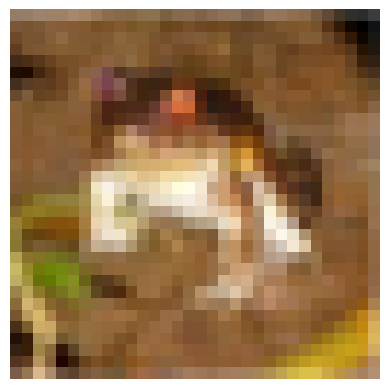

In [9]:
def imshow(img, lbl = None):
  img = img / 2 + 0.5     # unnormalize
  plt.imshow(img.permute(1, 2, 0))
  if lbl:
    plt.title(class_names[lbl])
  plt.axis(False)

imshow(image)

In [10]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2 # number of subprocesses to use for data loading
)

test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2  # number of subprocesses to use for data loading
)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x24df8077550>,
 <torch.utils.data.dataloader.DataLoader at 0x24de2997d60>)

frog  horse ship  airplane automobile horse cat   horse horse airplane truck ship  frog  frog  ship  ship  automobile frog  ship  deer  frog  airplane airplane frog  airplane automobile deer  bird  frog  dog   frog  dog  


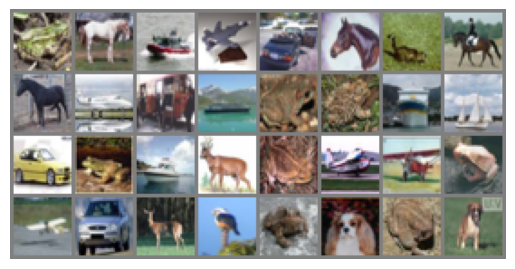

In [11]:
# get some random training images
dataiter = iter(train_dataloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{class_names[labels[j]]:5s}' for j in range(BATCH_SIZE)))

In [12]:
import torch.nn as nn
import torch.nn.functional as F
from helper_functions import accuracy_fn

In [13]:
class NetV2(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(3, 6, 5),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(6, 16, 5),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
          nn.Flatten(),
          nn.Linear(16 * 5 * 5, 120),
          nn.ReLU(),
          nn.Dropout(p=0.2),
          nn.Linear(120, 84),
          nn.ReLU(),
          nn.Dropout(p=0.2),
          nn.Linear(84, 10)
        )

    def forward(self, x):
      x = self.conv_block_1(x)
      # print("After conv_block_1:", x.shape)

      x = self.conv_block_2(x)
      # print("After conv_block_2:", x.shape)

      x = self.classifier(x)
      return x

net_2 = NetV2()

In [14]:
def train_step(model: torch.nn.Module, dataloader:torch.utils.data.DataLoader, loss_fn: torch.nn.Module, optimizer: torch.optim.Optimizer, device=device):
  model.train()

  train_loss, train_acc = 0, 0

  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)

    y_pred = model(X)

    loss = loss_fn(y_pred, y)
    train_loss += loss.item()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
    # train_acc += (y_pred_class == y).sum().item()/len(y_pred)
    train_acc += accuracy_fn(y_true=y, y_pred=y_pred_class)

  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)

  return train_loss, train_acc

In [15]:
def test_step(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, device=device):
  model.eval()

  test_loss, test_acc = 0, 0

  with torch.inference_mode():
    for batch, (X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)

      test_pred_logits = model(X)

      loss = loss_fn(test_pred_logits, y)
      test_loss += loss.item()

      test_pred_labels = test_pred_logits.argmax(dim=1)
      # test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))
      test_acc += accuracy_fn(y_true=y, y_pred=test_pred_labels)

  test_loss = test_loss / len(dataloader)
  test_acc = test_acc / len(dataloader)

  return test_loss, test_acc

In [16]:
from tqdm.auto import tqdm

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5,
          device: torch.device = device):

  results = {"train_loss": [],
             "train_acc": [],
             "test_loss": [],
             "test_acc": []}

  model.to(device)

  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_step(model=model,
                                        dataloader=train_dataloader,
                                        loss_fn=loss_fn,
                                        optimizer=optimizer,
                                        device=device)
    test_loss, test_acc = test_step(model=model,
                                    dataloader=test_dataloader,
                                    loss_fn=loss_fn,
                                    device=device)

    print(
        f"Epoch: {epoch+1} | "
        f"train_loss: {train_loss:.4f} | "
        f"train_acc: {train_acc: 4f} | "
        f"test_acc: {test_acc:.4f} | "
        f"test_loss: {test_loss:.4f}"
    )

    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)

  return results

c:\Users\kompo\Desktop\PyTorch\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
import torch.optim as optim
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(net_2.parameters(), lr=0.001, momentum=0.9)

In [18]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

EPOCHS = 35

from timeit import default_timer as timer
start_time = timer()

results = train(model=net_2,
                train_dataloader=train_dataloader,
                test_dataloader=test_dataloader,
                optimizer=optimizer,
                loss_fn=loss_fn,
                epochs=EPOCHS,
                device=device)

end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  3%|▎         | 1/35 [00:42<23:59, 42.34s/it]

Epoch: 1 | train_loss: 2.1722 | train_acc:  18.614044 | test_acc: 31.2200 | test_loss: 1.9146


  6%|▌         | 2/35 [01:19<21:43, 39.49s/it]

Epoch: 2 | train_loss: 1.8460 | train_acc:  32.125720 | test_acc: 38.3786 | test_loss: 1.6858


  9%|▊         | 3/35 [01:56<20:26, 38.32s/it]

...

Epoch: 33 | train_loss: 0.9376 | train_acc:  67.166507 | test_acc: 66.5935 | test_loss: 0.9461


 97%|█████████▋| 34/35 [21:03<00:34, 34.60s/it]

Epoch: 34 | train_loss: 0.9317 | train_acc:  67.240483 | test_acc: 66.8431 | test_loss: 0.9588


100%|██████████| 35/35 [21:40<00:00, 37.16s/it]

Epoch: 35 | train_loss: 0.9243 | train_acc:  67.578375 | test_acc: 67.3223 | test_loss: 0.9352
Total training time: 1300.843 seconds


In [19]:
from typing import Tuple, Dict, List

def plot_loss_curves(results: Dict[str, List[float]]):
  loss = results["train_loss"]
  test_loss = results["test_loss"]

  accuracy = results["train_acc"]
  test_accuracy = results["test_acc"]

  epochs = range(len(results["train_loss"]))

  plt.figure(figsize=(15, 7))

  plt.subplot(1, 2, 1)
  plt.plot(epochs, loss, label="train_loss")
  plt.plot(epochs, test_loss, label="test_loss")
  plt.title("Loss")
  plt.xlabel("Epochs")
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(epochs, accuracy, label="train_accuracy")
  plt.plot(epochs, test_accuracy, label="test_accuracy")
  plt.title("Accuracy")
  plt.xlabel("Epochs")
  plt.legend()

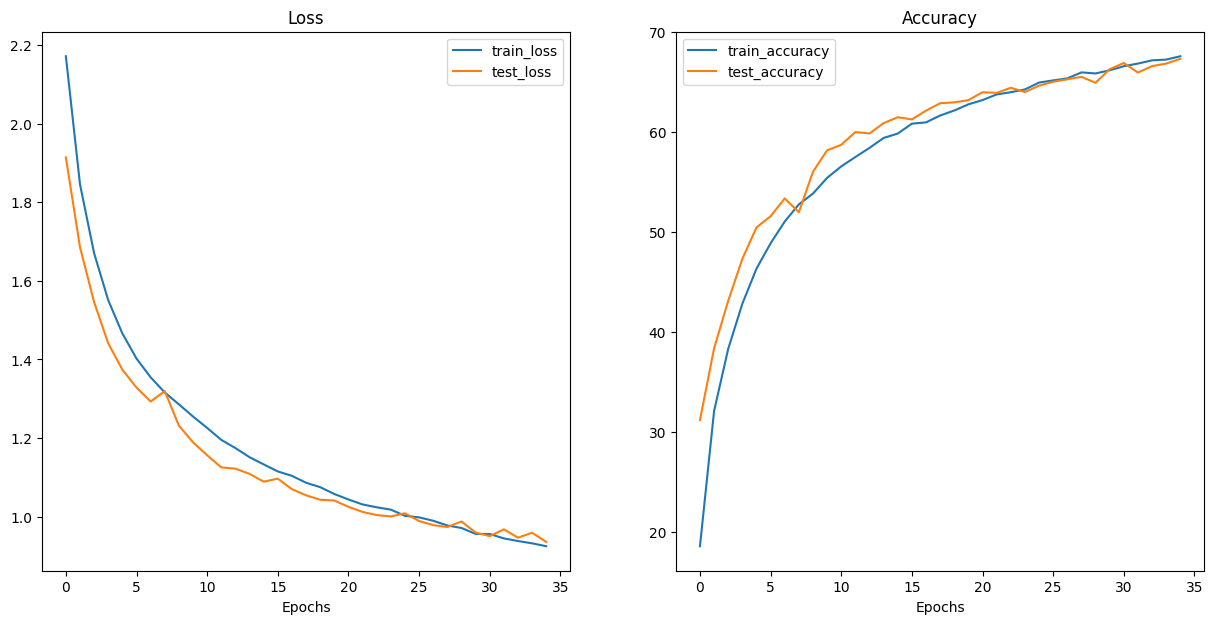

In [20]:
plot_loss_curves(results)